# Predicting Long-Term Revenue Potential with Random Forest

**Business Question:** How can we predict long-term revenue potential to prioritize high-value customers?

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('Libraries loaded.')

Libraries loaded.


In [6]:
def clean_columns(df):
    """Normalise column names: strip whitespace/tabs/newlines, lowercase, spaces to underscore."""
    df = df.copy()
    df.columns = (
        df.columns
        .str.replace('\n', '', regex=False)
        .str.replace('\t', '', regex=False)
        .str.strip()
        .str.lower()
        .str.replace(' ', '_', regex=False)
    )
    return df


# Load and immediately normalise
households = (
    pd.read_csv('../data/400_households.csv')
    .pipe(clean_columns)
    .rename(columns={'l': 'loyalty_flag'})
)

products = (
    pd.read_csv('../data/400_products.csv')
    .pipe(clean_columns)
)

transactions = (
    pd.read_csv('../data/400_transactions.csv')
    .pipe(clean_columns)
    .rename(columns={'purchase_': 'purchase_date'})
)

# Print actual column names so you can verify before proceeding
for name, df in [('households', households), ('products', products), ('transactions', transactions)]:
    print(f'{name}: {list(df.columns)}')

households: ['hshd_num', 'loyalty_flag', 'age_range', 'marital', 'income_range', 'homeowner', 'hshd_composition', 'hh_size', 'children']
products: ['product_num', 'department', 'commodity', 'brand_ty', 'natural_organic_flag']
transactions: ['basket_num', 'hshd_num', 'purchase_date', 'product_num', 'spend', 'units', 'store_r', 'week_num', 'year']


In [7]:
# Transactions
transactions['hshd_num']      = transactions['hshd_num'].astype(str).str.strip()
transactions['product_num']   = transactions['product_num'].astype(str).str.strip()
transactions['spend']         = pd.to_numeric(transactions['spend'],    errors='coerce').fillna(0)
transactions['units']         = pd.to_numeric(transactions['units'],    errors='coerce').fillna(0)
transactions['week_num']      = pd.to_numeric(transactions['week_num'], errors='coerce')
transactions['year']          = pd.to_numeric(transactions['year'],     errors='coerce')
transactions['purchase_date'] = pd.to_datetime(
    transactions['purchase_date'], dayfirst=True, errors='coerce'
)

# Households — replace literal 'null' strings that sometimes survive CSV export
households['hshd_num'] = households['hshd_num'].astype(str).str.strip()
households.replace('null', np.nan, inplace=True)

# Products
products['product_num'] = products['product_num'].astype(str).str.strip()

# Missing value report
print('Missing values per dataset:')
for name, df in [('households', households), ('products', products), ('transactions', transactions)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(f'\n--- {name} ---')
    print(missing.to_string() if len(missing) else 'None')

Missing values per dataset:

--- households ---
children    228

--- products ---
None

--- transactions ---
None


In [8]:
snapshot_date = transactions['purchase_date'].max() + pd.Timedelta(days=1)

rfm = transactions.groupby('hshd_num').agg(
    total_spend        = ('spend',        'sum'),
    avg_basket_spend   = ('spend',        'mean'),
    max_basket_spend   = ('spend',        'max'),
    total_trips        = ('basket_num',   'nunique'),
    total_items        = ('units',        'sum'),
    avg_items_per_trip = ('units',        'mean'),
    last_purchase      = ('purchase_date','max'),
    first_purchase     = ('purchase_date','min'),
).reset_index()

rfm['recency_days']   = (snapshot_date - rfm['last_purchase']).dt.days
rfm['tenure_days']    = (rfm['last_purchase'] - rfm['first_purchase']).dt.days
rfm['trips_per_week'] = rfm['total_trips'] / (rfm['tenure_days'].replace(0, 1) / 7)
rfm.drop(columns=['last_purchase', 'first_purchase'], inplace=True)

print('RFM features:')
display(rfm.head())

RFM features:


,hshd_num,total_spend,avg_basket_spend,max_basket_spend,total_trips,total_items,avg_items_per_trip,recency_days,tenure_days,trips_per_week
0,10,9454.91,5.712937,78.81,165,1956,1.181873,1,727,1.588721
1,1012,4411.08,2.738101,21.37,117,2188,1.358163,4,719,1.139082
2,1015,10558.83,3.076582,34.99,273,4218,1.229021,10,720,2.654167
3,1020,12932.98,3.961096,61.96,687,4042,1.237979,1,729,6.596708
4,1034,16971.78,2.555991,26.17,347,8031,1.209488,3,727,3.341128


In [9]:
tx_prod = transactions.merge(products, on='product_num', how='left')

diversity = tx_prod.groupby('hshd_num').agg(
    unique_products    = ('product_num',         'nunique'),
    unique_departments = ('department',           'nunique'),
    unique_commodities = ('commodity',            'nunique'),
    private_label_rate = ('brand_ty',             lambda x: (x.str.strip().str.upper() == 'PRIVATE').mean()),
    organic_rate       = ('natural_organic_flag', lambda x: (x.str.strip().str.upper() == 'Y').mean()),
).reset_index()

print('Diversity features:')
display(diversity.head())

Diversity features:


,hshd_num,unique_products,unique_departments,unique_commodities,private_label_rate,organic_rate
0,10,749,3,30,0.229607,0.018127
1,1012,787,3,26,0.342024,0.015518
2,1015,1600,3,33,0.489219,0.012529
3,1020,1336,3,38,0.324962,0.009801
4,1034,2011,3,36,0.436145,0.004066


In [ ]:
HH_SIZE_COL  = 'hh_size'
CHILDREN_COL = 'children'

# Ordinal maps (values matched case-insensitively via .str.upper() below)
income_order  = ['UNDER 35K', '35-49K', '50-74K', '75-99K', '100-150K', '150K+']
age_order     = ['19-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+']
hh_size_order = ['1', '2', '3', '4', '5+']

def safe_ordinal(series, order):
    """Map to ordinal int (0-based). NaN or unrecognised values become -1."""
    order_map = {v.upper(): i for i, v in enumerate(order)}
    return (
        series
        .astype(str)
        .str.strip()
        .str.upper()
        .map(order_map)
        .fillna(-1)
        .astype(int)
    )

hh = households.copy()

hh['income_ord']  = safe_ordinal(hh['income_range'], income_order)
hh['age_ord']     = safe_ordinal(hh['age_range'],    age_order)
hh['hh_size_ord'] = safe_ordinal(hh[HH_SIZE_COL],   hh_size_order)

hh['has_children'] = (
    hh[CHILDREN_COL].astype(str).str.strip().str.upper() == 'Y'
).astype(int)

hh['is_loyal'] = (
    hh['loyalty_flag'].astype(str).str.strip().str.upper() == 'Y'
).astype(int)

hh['is_homeowner'] = (
    hh['homeowner'].astype(str).str.strip().str.upper() == 'HOMEOWNER'
).astype(int)

hh['marital_enc'] = LabelEncoder().fit_transform(
    hh['marital'].fillna('unknown').astype(str).str.strip().str.upper()
)
hh['comp_enc'] = LabelEncoder().fit_transform(
    hh['hshd_composition'].fillna('unknown').astype(str).str.strip().str.upper()
)

demo_cols = [
    'hshd_num', 'income_ord', 'age_ord', 'hh_size_ord',
    'has_children', 'is_loyal', 'is_homeowner', 'marital_enc', 'comp_enc'
]

print('Encoded demographic sample:')
display(hh[demo_cols].head())

Encoded demographic sample:


,hshd_num,income_ord,age_ord,hh_size_ord,has_children,is_loyal,is_homeowner,marital_enc,comp_enc
0,1600,-1,-1,-1,0,1,0,1,4
1,159,-1,-1,-1,0,1,0,1,4
2,210,-1,-1,-1,0,1,0,1,4
3,616,-1,-1,-1,0,1,0,1,4
4,651,-1,-1,-1,0,1,0,1,4


In [12]:
features = (
    rfm
    .merge(diversity,     on='hshd_num', how='left')
    .merge(hh[demo_cols], on='hshd_num', how='left')
)
features.fillna(0, inplace=True)

print(f'Feature table: {features.shape[0]} households x {features.shape[1]} columns')
display(features.head())

Feature table: 400 households x 23 columns


,hshd_num,total_spend,avg_basket_spend,max_basket_spend,total_trips,total_items,avg_items_per_trip,recency_days,tenure_days,trips_per_week,...,private_label_rate,organic_rate,income_ord,age_ord,hh_size_ord,has_children,is_loyal,is_homeowner,marital_enc,comp_enc
0,10,9454.91,5.712937,78.81,165,1956,1.181873,1,727,1.588721,...,0.229607,0.018127,1,3,0,0,1,1,2,0
1,1012,4411.08,2.738101,21.37,117,2188,1.358163,4,719,1.139082,...,0.342024,0.015518,0,5,2,0,0,1,0,3
2,1015,10558.83,3.076582,34.99,273,4218,1.229021,10,720,2.654167,...,0.489219,0.012529,0,3,3,0,1,1,2,1
3,1020,12932.98,3.961096,61.96,687,4042,1.237979,1,729,6.596708,...,0.324962,0.009801,5,4,3,0,1,1,0,3
4,1034,16971.78,2.555991,26.17,347,8031,1.209488,3,727,3.341128,...,0.436145,0.004066,1,1,4,0,1,0,2,1


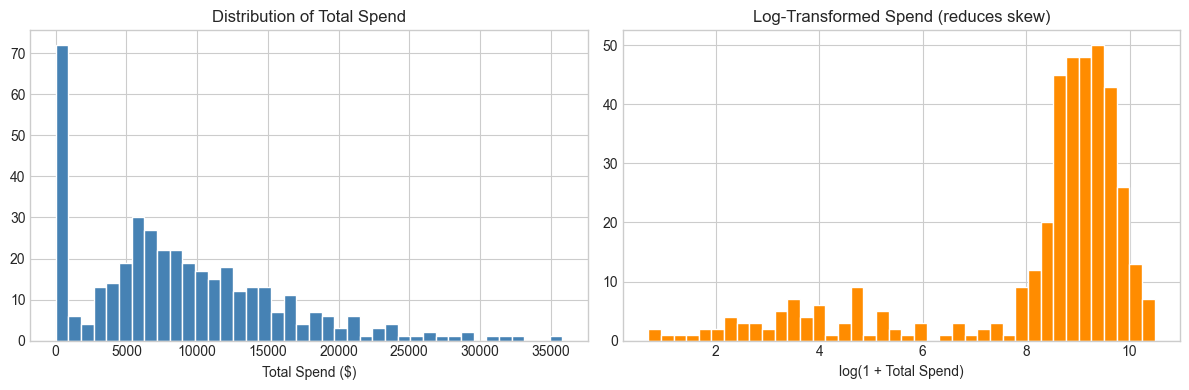

In [13]:
TARGET = 'total_spend'
X = features.drop(columns=['hshd_num', TARGET])
y = features[TARGET]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Total Spend')
axes[0].set_xlabel('Total Spend ($)')

axes[1].hist(np.log1p(y), bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Log-Transformed Spend (reduces skew)')
axes[1].set_xlabel('log(1 + Total Spend)')

plt.tight_layout()
plt.show()

y_log = np.log1p(y)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators     = 300,
    max_depth        = 12,
    min_samples_leaf = 3,
    max_features     = 'sqrt',
    random_state     = 42,
    n_jobs           = -1
)
rf.fit(X_train, y_train)
print('Model trained.')

Model trained.


────────────────────────────────────────
  MAE            : $1,233.75
  RMSE           : $2,305.87
  R2             : 0.8922
  5-Fold CV R2   : 0.9872 +/- 0.0017
────────────────────────────────────────


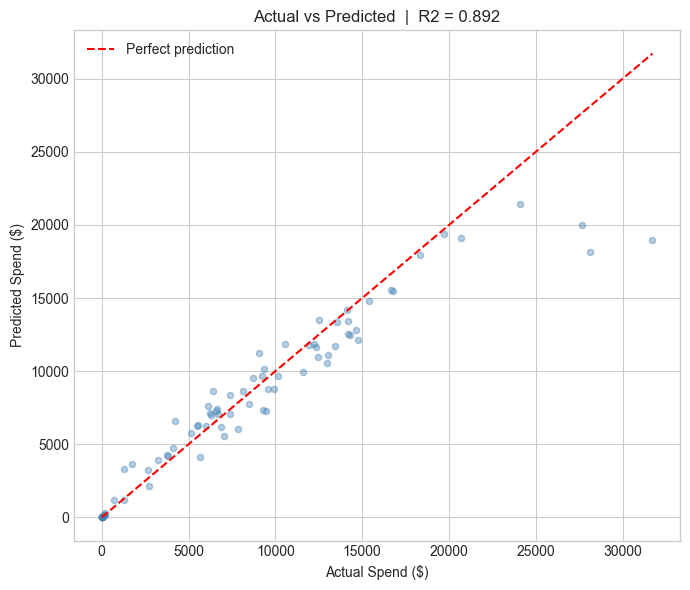

In [15]:
y_pred_log  = rf.predict(X_test)
y_pred      = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)

mae  = mean_absolute_error(y_test_orig, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
r2   = r2_score(y_test_orig, y_pred)
cv_scores = cross_val_score(rf, X, y_log, cv=5, scoring='r2', n_jobs=-1)

print('─' * 40)
print(f'  MAE            : ${mae:,.2f}')
print(f'  RMSE           : ${rmse:,.2f}')
print(f'  R2             : {r2:.4f}')
print(f'  5-Fold CV R2   : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print('─' * 40)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test_orig, y_pred, alpha=0.4, s=20, color='steelblue')
lims = [0, max(y_test_orig.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Spend ($)')
ax.set_ylabel('Predicted Spend ($)')
ax.set_title(f'Actual vs Predicted  |  R2 = {r2:.3f}')
ax.legend()
plt.tight_layout()
plt.show()

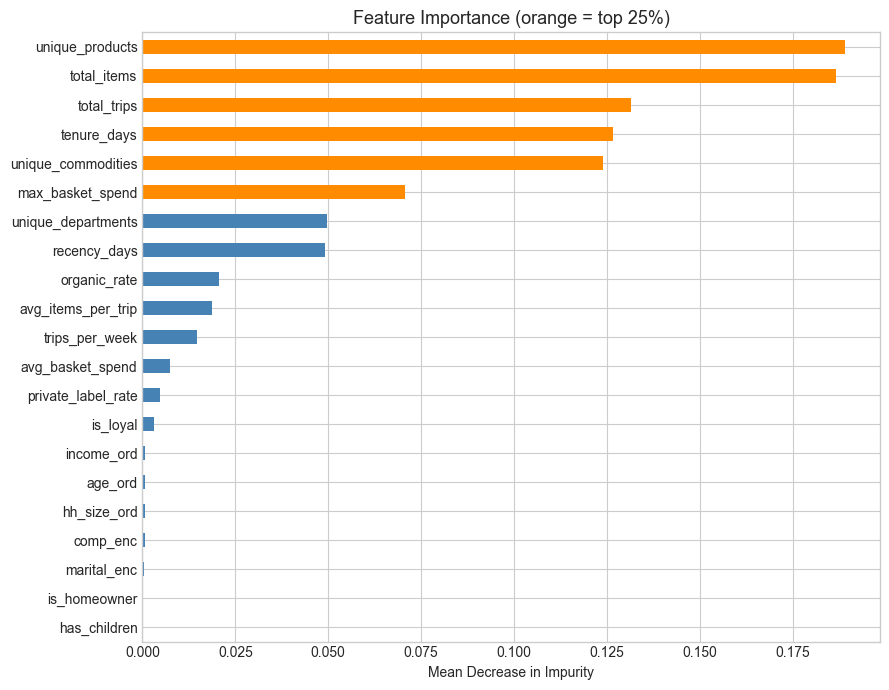

Top 10 features:
unique_products       0.188972
total_items           0.186529
total_trips           0.131439
tenure_days           0.126612
unique_commodities    0.123778
max_basket_spend      0.070622
unique_departments    0.049658
recency_days          0.049105
organic_rate          0.020727
avg_items_per_trip    0.018816


In [16]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

colors = ['darkorange' if v >= importances.quantile(0.75) else 'steelblue'
          for v in importances]

fig, ax = plt.subplots(figsize=(9, 7))
importances.plot.barh(ax=ax, color=colors)
ax.set_title('Feature Importance (orange = top 25%)', fontsize=13)
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(importances.sort_values(ascending=False).head(10).to_string())

In [17]:
features['predicted_revenue'] = np.expm1(rf.predict(X))

features['revenue_tier'] = pd.qcut(
    features['predicted_revenue'],
    q=[0, 0.5, 0.75, 0.90, 1.0],
    labels=['Bronze', 'Silver', 'Gold', 'Platinum']
)

priority_df = (
    features[['hshd_num', 'total_spend', 'predicted_revenue',
               'revenue_tier', 'total_trips', 'recency_days',
               'income_ord', 'is_loyal']]
    .sort_values('predicted_revenue', ascending=False)
    .reset_index(drop=True)
)
priority_df.index += 1
priority_df.index.name = 'rank'

print('=== TOP 20 HIGH-VALUE CUSTOMERS ===')
display(priority_df.head(20))

=== TOP 20 HIGH-VALUE CUSTOMERS ===


,hshd_num,total_spend,predicted_revenue,revenue_tier,total_trips,recency_days,income_ord,is_loyal
rank,,,,,,,,
1,2629,29054.05,24257.379598,Platinum,584,1,3,1
2,1245,29224.17,24048.670913,Platinum,469,2,4,1
3,2512,32915.63,23168.930603,Platinum,845,1,4,1
4,1082,25848.44,23120.924257,Platinum,620,1,0,1
5,60,30628.33,22850.394563,Platinum,590,1,1,1
6,991,25006.31,21977.858116,Platinum,1517,1,2,1
7,4078,24072.08,21401.449698,Platinum,726,2,5,1
8,1265,22285.37,21142.181402,Platinum,264,6,5,1
9,3496,26374.71,21026.199212,Platinum,320,8,2,1


,customer_count,avg_predicted_rev,avg_actual_spend,avg_trips,avg_recency,loyal_rate
revenue_tier,,,,,,
Bronze,200,3554.41,3485.19,105.54,129.72,0.58
Silver,100,9988.32,10096.12,258.10,4.73,0.82
Gold,60,14208.95,14931.87,344.60,3.20,0.98
Platinum,40,19794.50,23097.56,443.58,2.55,1.00


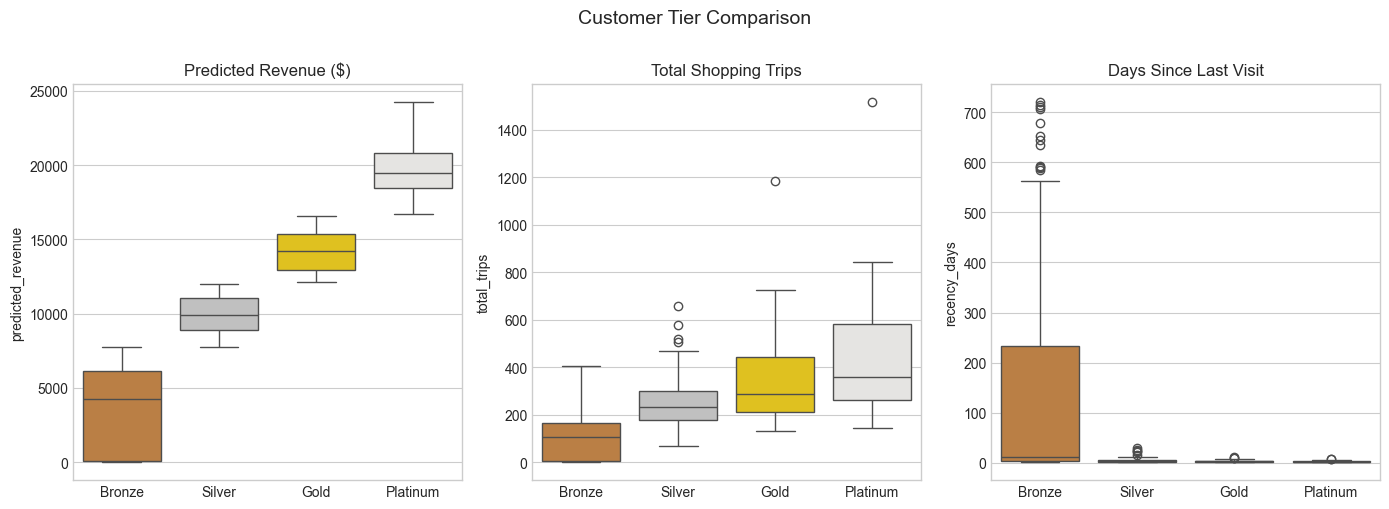

In [18]:
tier_summary = (
    features.groupby('revenue_tier', observed=True)
    .agg(
        customer_count    = ('hshd_num',          'count'),
        avg_predicted_rev = ('predicted_revenue',  'mean'),
        avg_actual_spend  = ('total_spend',        'mean'),
        avg_trips         = ('total_trips',        'mean'),
        avg_recency       = ('recency_days',       'mean'),
        loyal_rate        = ('is_loyal',           'mean'),
    )
    .round(2)
)
display(tier_summary)

tier_order = ['Bronze', 'Silver', 'Gold', 'Platinum']
palette    = ['#cd7f32', '#C0C0C0', '#FFD700', '#E5E4E2']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (col, label) in zip(axes, [
    ('predicted_revenue', 'Predicted Revenue ($)'),
    ('total_trips',       'Total Shopping Trips'),
    ('recency_days',      'Days Since Last Visit'),
]):
    sns.boxplot(data=features, x='revenue_tier', y=col,
                order=tier_order, palette=palette, ax=ax)
    ax.set_title(label)
    ax.set_xlabel('')

plt.suptitle('Customer Tier Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

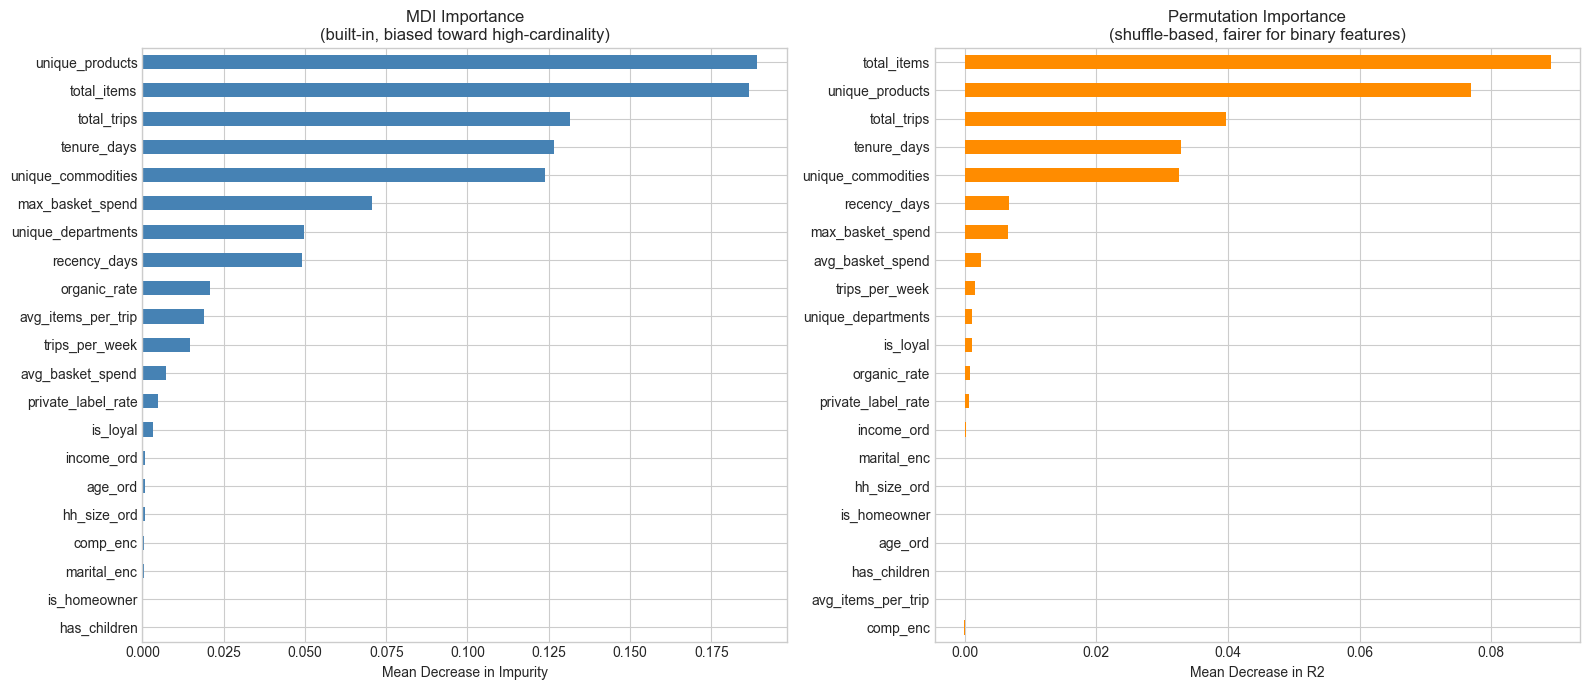

Permutation Importance (top 10):
total_items           0.089026
unique_products       0.076943
total_trips           0.039683
tenure_days           0.032809
unique_commodities    0.032625
recency_days          0.006691
max_basket_spend      0.006554
avg_basket_spend      0.002463
trips_per_week        0.001599
unique_departments    0.001150


In [19]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Use bracket access instead of attribute access
perm_imp = (
    pd.Series(result['importances_mean'], index=X.columns)
    .sort_values(ascending=True)
)

# Plot alongside MDI for comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

mdi_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

mdi_imp.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('MDI Importance\n(built-in, biased toward high-cardinality)')
axes[0].set_xlabel('Mean Decrease in Impurity')

perm_imp.plot.barh(ax=axes[1], color='darkorange')
axes[1].set_title('Permutation Importance\n(shuffle-based, fairer for binary features)')
axes[1].set_xlabel('Mean Decrease in R2')

plt.tight_layout()
plt.show()

print('Permutation Importance (top 10):')
print(perm_imp.sort_values(ascending=False).head(10).to_string())